In [3]:
%pip install factor_analyzer --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
resmat = pd.read_pickle("../data/resmat.pkl")

In [24]:
resmat.shape

(183, 78712)

In [19]:
import torch
import numpy as np
from factor_analyzer.rotator import Rotator

# 1) Load parameters
model_data = torch.load('./output/mirt_model_k7.pt', map_location=torch.device('cpu'))
theta = model_data['theta']          # shape: (n_people, k)
a = model_data['a']                  # shape: (n_items,  k)
b = model_data['b']

print("--- Initial Loaded Data ---")
print(f"Original theta shape: {theta.shape}")
print(f"Original 'a' matrix shape: {a.shape}\n")

a_numpy = a.detach().cpu().numpy()
theta_numpy = theta.detach().cpu().numpy()

# 2) Rotate 'a'
rotator = Rotator(method='varimax')  # orthogonal
a_rotated_numpy = rotator.fit_transform(a_numpy)
print("--- After Rotation of 'a' ---")
print(f"Rotated 'a' matrix shape: {a_rotated_numpy.shape}\n")

# 3) Transform theta using the SAME rotation matrix from Rotator
T = rotator.rotation_                # <- correct attribute on Rotator
theta_transformed_numpy = theta_numpy @ T  # for orthogonal varimax, use R (not inv(R))

print("--- After Transformation of 'theta' ---")
print(f"Transformed theta shape: {theta_transformed_numpy.shape}\n")

# (Optional) Sanity check: inner products preserved (up to numerical tolerance)
# err = np.max(np.abs(a_numpy @ theta_numpy.T - a_rotated_numpy @ theta_transformed_numpy.T))
# print(f"Max abs diff in item-person inner products: {err:.3e}")

# 4) Standardize transformed theta
mean_transformed = np.mean(theta_transformed_numpy, axis=0)
std_transformed = np.std(theta_transformed_numpy, axis=0)
eps = 1e-8
theta_z_scores_numpy = (theta_transformed_numpy - mean_transformed) / np.maximum(std_transformed, eps)

print("--- Final Standardized Z-Scores (from transformed theta) ---")
print("These are the scores you should use for interpretation.")
print(theta_z_scores_numpy)

# Convert back to torch if needed
a_rotated = torch.from_numpy(a_rotated_numpy).float()
theta_transformed = torch.from_numpy(theta_transformed_numpy).float()
theta_z_scores = torch.from_numpy(theta_z_scores_numpy).float()


--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 7])
Original 'a' matrix shape: torch.Size([78712, 7])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 7)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 7)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[-2.79948482 -0.78202985 -1.93298756 ...  0.23071324  0.89549107
   2.23566031]
 [ 0.14613676  1.83059008 -1.83839537 ... -0.57835935  0.86668647
   1.05314883]
 [-0.21110577 -1.11797513 -1.46836547 ...  1.00485595 -0.20510633
   0.43915629]
 ...
 [-2.43912155 -2.26166166  1.05527517 ...  0.51826374 -0.07370304
   0.66003036]
 [-2.81758287 -2.32154915  0.75505565 ... -0.15213182 -0.11226068
   1.30435391]
 [-2.54270949 -0.91331091 -0.32832385 ...  1.38565465 -0.07441711
  -0.09826813]]



Generating ability heatmap...
Top 20 models by sum of abilities:
                                             F1     F2     F3     F4     F5  \
request.model                                                                 
meta/llama-3.2-90b-vision-instruct-turbo  0.809 -0.499  1.841 -0.728 -0.155   
meta/llama-3.1-70b-instruct-turbo         0.943 -0.363  1.705 -0.833  0.003   
openai/gpt-4o-2024-05-13                  0.076 -1.333  1.704 -0.920  1.091   
openai/gpt-4-0613                        -0.550 -1.471  1.619  0.247  0.849   
meta/llama-3.1-405b-instruct-turbo       -0.891 -0.640  1.608 -1.585  0.663   
openai/gpt-3.5-turbo-0301                -1.605  1.094  1.484  0.421 -0.097   
writer/palmyra-x-v3                      -0.062 -1.123  1.472  0.805 -2.210   
qwen/qwen2.5-72b-instruct-turbo          -0.414 -1.282  1.421 -0.319  0.726   
meta/llama-3.3-70b-instruct-turbo         0.139 -0.317  1.412 -0.257  0.588   
openai/gpt-4o-2024-08-06                 -0.385 -1.493  1.405 -0.

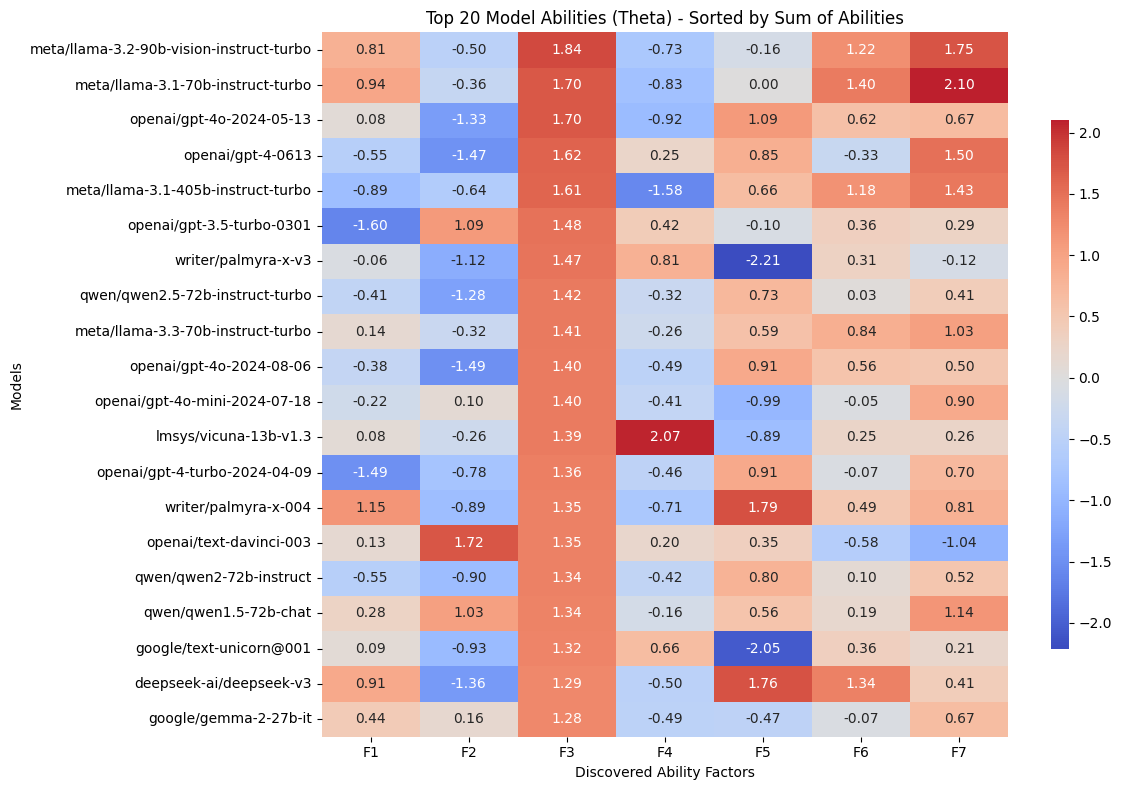


Sum of abilities for top 20 models:
meta/llama-3.2-90b-vision-instruct-turbo: 4.231
meta/llama-3.1-70b-instruct-turbo: 4.953
openai/gpt-4o-2024-05-13: 1.902
openai/gpt-4-0613: 1.864
meta/llama-3.1-405b-instruct-turbo: 1.763
openai/gpt-3.5-turbo-0301: 1.950
writer/palmyra-x-v3: -0.933
qwen/qwen2.5-72b-instruct-turbo: 0.573
meta/llama-3.3-70b-instruct-turbo: 3.437
openai/gpt-4o-2024-08-06: 1.005
openai/gpt-4o-mini-2024-07-18: 0.730
lmsys/vicuna-13b-v1.3: 2.908
openai/gpt-4-turbo-2024-04-09: 0.174
writer/palmyra-x-004: 3.986
openai/text-davinci-003: 2.128
qwen/qwen2-72b-instruct: 0.896
qwen/qwen1.5-72b-chat: 4.390
google/text-unicorn@001: -0.360
deepseek-ai/deepseek-v3: 3.858
google/gemma-2-27b-it: 1.503


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# ===================================================================
# F) Create and Plot the Theta Heatmap
# ===================================================================
print("\nGenerating ability heatmap...")

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores.detach().cpu().numpy()
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)
# iq_scores_df = (ability_df * 15) + 100

# Step 3: Calculate sum of abilities and sort
ability_df['sum_abilities'] = ability_df.sum(axis=1)
ability_df_sorted = ability_df.sort_values(by='F3', ascending=False)

# Step 4: Set the number of top models to display
k = 20  # Change this value to display top k models
top_models_df = ability_df_sorted.head(k).drop(columns='sum_abilities')

print(f"Top {k} models by sum of abilities:")
print(top_models_df.round(3))

# Step 5: Generate the heatmap using Seaborn
plt.figure(figsize=(12, max(8, k * 0.4)))
sns.heatmap(
	top_models_df,
	annot=True,
	cmap='coolwarm',
	center=0,
	fmt=".2f",
	cbar_kws={'shrink': 0.75, 'aspect': 30}
)
plt.title(f'Top {k} Model Abilities (Theta) - Sorted by Sum of Abilities')
plt.xlabel('Discovered Ability Factors')
plt.ylabel('Models')
plt.tight_layout()
plt.savefig(f"mirt_theta_heatmap_top{k}.png", dpi=300, bbox_inches='tight')
plt.show()

# Optional: Show summary statistics
print(f"\nSum of abilities for top {k} models:")
for model in top_models_df.index:
	sum_ability = ability_df_sorted.loc[model, 'sum_abilities']
	print(f"{model}: {sum_ability:.3f}")